In [151]:
import pandas as pd
import json
import plotly.express as px
import numpy as np
import seaborn as sns

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn import tree


In [2]:
with open('./user_course_info_cleaned.json', 'r') as file:
    user_course_info = json.load(file)

df_user_course_info = pd.DataFrame(user_course_info)

In [3]:
with open('./teacher_stats_cleaned.json', 'r') as file:
    teacher_stats = json.load(file)

df_teacher_stats = pd.DataFrame(teacher_stats)

In [4]:
with open('./pro_course_cleaned.json', 'r') as file:
    pro_course = json.load(file)

df_pro_course = pd.DataFrame(pro_course)

In [5]:
with open('./price_list_cleaned.json', 'r') as file:
    price_list = json.load(file)

df_price_list = pd.DataFrame(price_list)

In [6]:
with open('./also_speaks_cleaned.json', 'r') as file:
    also_speaks = json.load(file)

df_also_speaks = pd.DataFrame(also_speaks)

In [7]:
with open('./also_speaks_reference.json', 'r') as file:
    also_speaks_reference = json.load(file)

df_also_speaks_reference = pd.DataFrame(also_speaks_reference)

Price Prediction Model Functions

In [135]:
def is_tutor(tutor):
    if tutor == True:
        df_tutors = df_user_course_info[(df_user_course_info['is_tutor'] == 1) & (df_user_course_info['is_pro']  == 0)]
        return df_tutors[['user_id', 'trial_session_count', 'trial_price']]
    else:
        df_pros_1 = df_user_course_info[(df_user_course_info['is_tutor'] == 1) & (df_user_course_info['is_pro']  == 1)]
        df_pros_2 = df_user_course_info[(df_user_course_info['is_tutor'] == 0) & (df_user_course_info['is_pro']  == 1)]
        df_pros_combined = pd.concat([df_pros_1, df_pros_2], ignore_index=True)
        df_pros_combined = df_pros_combined[['user_id', 'trial_session_count', 'trial_price']]
        return df_pros_combined
        
        
is_tutor(True)

,user_id,trial_session_count,trial_price
0,55502,97,1000
3,132815,0,750
6,249152,70,800
11,355886,142,500
12,368484,91,1000
...,...,...,...
10465,32167939,3,1000
10466,32168520,0,500
10467,32169200,0,1400
10468,32169731,0,600


In [136]:
def teacher_id_language(language):
    df_teachers_id = df_pro_course[df_pro_course['language'] == language].groupby(['teacher_id', 'language']).count()
    df_teachers_id = df_teachers_id.reset_index()
    df_teachers_id = df_teachers_id[['teacher_id']]
    return df_teachers_id

teacher_id_language('chinese')

,teacher_id
0,55502
1,113638
2,114708
3,259649
4,436016
...,...
993,31845535
994,31847889
995,31913484
996,31915782


In [137]:
def pro_course_language(language):
    df_pro_course_target = df_pro_course[df_pro_course['language'] == language]
    return df_pro_course_target

pro_course_language('english')

,id,teacher_id,language,title,session_price,student_count,session_count,has_package
0,375,436016,english,English courses新概念英语（1）,1400,15,106,0
4,4042,463477,english,One-on-One tutoring: English,3200,95,1504,1
6,5779,502096,english,One-on-One tutoring: English,2300,84,876,1
17,10048,596847,english,English language instruction,2600,147,2881,1
21,10779,483024,english,English Pronunciation & Intonation,6500,49,90,1
...,...,...,...,...,...,...,...,...
39014,290713,18491956,english,IELTS Preparation Course,800,0,0,1
39015,290714,18491956,english,"Medical, Health & Fitness English",800,0,0,1
39017,290721,5846271,english,"Beginner English (for FR, ES, PT, ZH speakers)",2200,0,0,1
39019,290736,19100180,english,English Language Topics Lesson,2300,0,0,1


In [153]:
def language_is_tutor(language, tutor):        
    df_tutor_pro = is_tutor(tutor)
    df_language = pro_course_language(language)
    df_merged = pd.merge(df_tutor_pro, df_language, left_on='user_id', right_on='teacher_id', how='inner')
    # df_merged = df_merged[['user_id', 'trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session_price']]
    df_merged = df_merged[['trial_session_count', 'trial_price', 'student_count', 'session_count', 'has_package', 'session_price']]
    return df_merged

language_is_tutor('french', True)

,trial_session_count,trial_price,student_count,session_count,has_package,session_price
0,0,1000,0,0,1,3000
1,296,1500,435,5178,1,2000
2,296,1500,16,238,1,2500
3,182,800,421,2738,1,1600
4,182,800,31,143,1,1800
...,...,...,...,...,...,...
1926,0,500,4,7,1,1000
1927,0,500,0,0,1,700
1928,0,2500,0,0,1,5000
1929,3,1000,0,0,0,2000


The courses that have less than 10 sessions or 10 trial sessions should be removed\
Since their progress has not yet stabilized, this should not be included in the training and test data.

In [154]:
df_model = language_is_tutor('english', True)
df_model = df_model[(df_model['session_count'] > 10) & (df_model['trial_session_count'] > 10)]
df_model

,trial_session_count,trial_price,student_count,session_count,has_package,session_price
1,440,1000,41,250,1,1400
2,440,1000,20,108,1,1400
3,440,1000,17,122,1,1400
10,91,1200,14,80,1,2000
19,422,1200,378,3651,1,2900
...,...,...,...,...,...,...
4522,34,500,9,13,0,2500
4523,34,500,6,28,1,2500
4532,13,700,26,77,0,1500
4540,11,500,6,11,1,800


<Axes: >

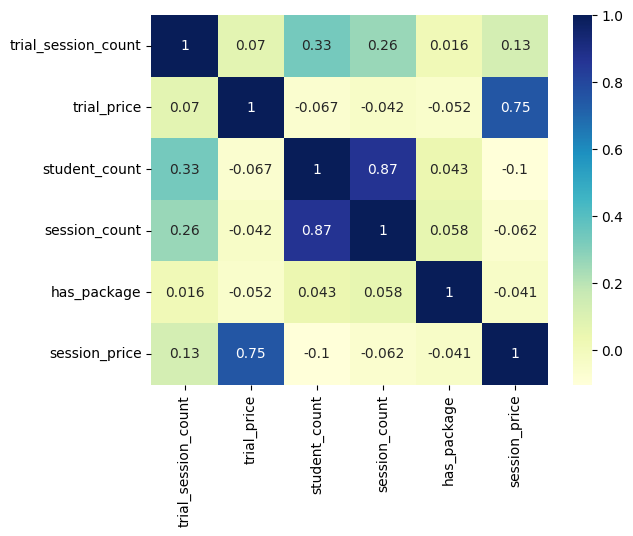

In [155]:
cor = df_model.corr()

#plot correlation heatmapn
sns.heatmap(cor, cmap="YlGnBu", annot=True)

In [156]:
fig = px.scatter(df_model, x="session_price", y="trial_price", trendline='ols')

# Display the interactive figure
fig.show()

In [157]:
features = list(df_model.columns)
features.pop(5)
features

['trial_session_count',
 'trial_price',
 'student_count',
 'session_count',
 'has_package']

In [158]:
X = df_model[features]
y = df_model['session_price']

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [167]:
regr_english_tutor = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
regr_english_tutor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [168]:
y_pred = regr_english_tutor.predict(X_test)

In [169]:
root_mean_squared_error(y_pred, y_test)

565.9573523793272

In [170]:
r2 = r2_score(y_test,y_pred)
r2

0.7176117916113622